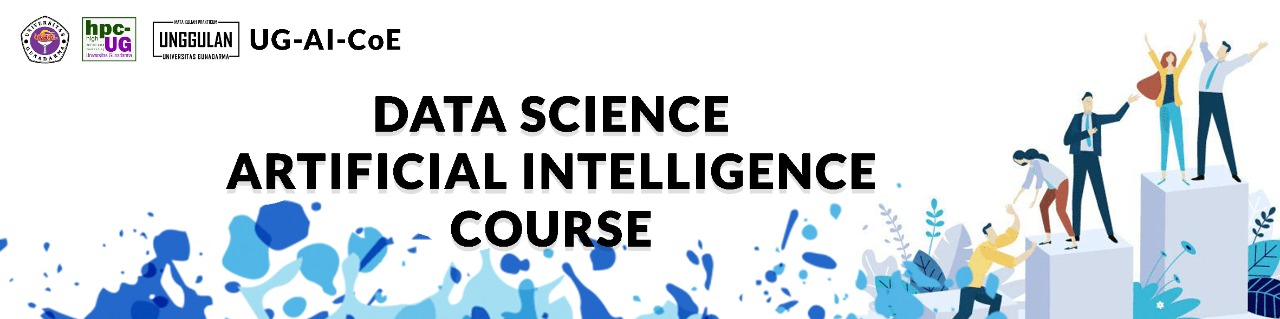

# Tugas Mandiri
---
Tugas mandiri ini digunakan pada kegiatan Kursus Data Science yang merupakan pembekalan bagi mahasiswa Universitas Gunadarma untuk Skema Supervisor Ilmuwan Data (Data Scientist Supervisor).

### Pertemuan 4 - Semester 7

## Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM


### Deskripsi Tugas
1. Mahasiswa harus membuat Project Data Science Sederhana dengan menggunakan algoritma clustering untuk menemukan kelompok atau pola tersembunyi pada suatu dataset.
2. Project dikerjakan secara lengkap mengikuti tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, mulai dari Business Understanding hingga tahap Deployment.
3. Mahasiswa bebas memilih topik atau permasalahan yang relevan, selama project memiliki tujuan clustering yang jelas dan dataset memenuhi ketentuan yang telah ditetapkan.

### Ketentuan Dataset

Dataset yang digunakan harus memenuhi ketentuan berikut:
1. Berupa tabular dataset (.csv, .xlsx, atau sejenisnya).
2. Minimal 1000 baris dan 8 kolom.
3. Memiliki minimal 3 fitur numerik yang dapat digunakan untuk clustering.
4. Dataset memiliki karakteristik yang memungkinkan untuk dilakukan pengelompokan atau segmentasi.
5. Sumber dataset wajib dicantumkan dan berasal dari sumber yang jelas, seperti Kaggle, UCI, data.go.id, open data, atau dataset hasil pengumpulan sendiri.
6. Mahasiswa wajib menjelaskan secara singkat alasan dataset tersebut sesuai untuk permasalahan clustering.


<b>Catatan: Nilai akan dikurangi apabila dataset tidak memenuhi ketentuan.</b>

### Ketentuan Pengumpulan

Mahasiswa wajib mengumpulkan file berikut:
1. File Jupyter Notebook dengan format (`.ipynb`): Berisi seluruh proses CRISP-DM dari Business Understanding sampai Evaluation. **Notebook harus dapat dijalankan tanpa error.**

2. File Dataset: File dataset yang digunakan atau link sumber dataset.

3. Source Code Deployment
    <br> File yang digunakan untuk menjalankan aplikasi, misalnya: <br>
         

    *   app.py
    *   requirements.txt
    *   file konfigurasi atau file pendukung lainnya.


4. Link Deployment: Link aplikasi yang sudah dapat diakses melalui platform Streamlit.

<br>

<b>Seluruh file project dikumpulkan dalam satu folder Google Drive dengan akses *Anyone with the link → Editor*.</b> Tautan folder Google Drive kemudian dikumpulkan melalui Virtual Class sesuai dengan batas waktu yang telah ditentukan.

---

### Daftar Isi:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Deployment

# 1. Business Understanding


### 1.1 Latar Belakang
Pasar properti memiliki variasi harga dan spesifikasi fisik rumah (seperti luas tanah, luas bangunan, jumlah kamar tidur, dan jumlah kamar mandi) yang sangat beragam. Bagi agen properti, pembeli, maupun pengembang, mengelompokkan jenis-jenis properti secara manual atau berpatokan pada harga saja sering kali kurang akurat. 

Pendekatan *Data Science* menggunakan teknik *Unsupervised Learning* (Clustering) dapat membantu menemukan pola tersembunyi (*hidden patterns*) serta mengelompokkan properti ke dalam segmentasi yang lebih jelas berdasarkan kemiripan spesifikasi fisiknya.

### 1.2 Rumusan Masalah
1. Bagaimana mengelompokkan (*clustering*) data properti/rumah berdasarkan spesifikasi fisik dan harga tanpa label yang terdefinisi sebelumnya?
2. Bagaimana mendeteksi properti yang memiliki karakteristik anomali/ekstrem (*outlier*) di luar pola harga pasar umum?
3. Bagaimana mengimplementasikan model *clustering* tersebut ke dalam antarmuka interaktif yang dapat digunakan pengguna secara praktis?

### 1.3 Tujuan Proyek
1. **Segmentasi Pasar:** Melakukan pengelompokan pasar properti menggunakan algoritma **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**.
2. **Deteksi Anomali:** Mengidentifikasi data *outlier/noise* (properti dengan kombinasi harga dan spesifikasi yang tidak wajar/ekstrem).
3. **Deployment:** Membangun dan merilis aplikasi web interaktif berbasis **Streamlit** untuk memprediksi segmentasi kluster dari input data properti baru secara *real-time*.

### 1.4 Rencana Keluaran (Deliverables)
1. File Jupyter Notebook (`.ipynb`) yang mencakup alur CRISP-DM lengkap dari Business Understanding hingga Evaluation.
2. Model *clustering* dan objek *scaler* yang tersimpan dalam format `.pkl`.
3. Source code aplikasi web (`app.py` dan `requirements.txt`).
4. Aplikasi Streamlit yang telah di-deploy dan dapat diakses publik via tautan (*link*).

In [1]:
# Import library awal untuk analisis data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Pengaturan tampilan
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("Tahap Business Understanding selesai direkam.")
print("Library dasar berhasil diimpor.")

Tahap Business Understanding selesai direkam.
Library dasar berhasil diimpor.


# 2. Data Understanding
---

### 2.1 Deskripsi dan Sumber Dataset
Sumber Dataset (Kaggle): **https://www.kaggle.com/code/alisyarahma/regresi-harga-rumah/input**. 
Dataset yang digunakan memuat data historis transaksi penjualan rumah di wilayah Washington, USA. Dataset ini terdiri dari **4.600 baris** dan **18 kolom** yang memuat informasi spesifikasi fisik rumah, lokasi, dan harga transaksi.

### Mengapa Dataset Ini Sesuai untuk Clustering?
Dataset ini memiliki kombinasi fitur numerik spesifikasi rumah (`sqft_living`, `bedrooms`, `bathrooms`, `sqft_lot`) dan variabel ekonomi (`price`). Variasi skala dan hubungan antar fitur ini memungkinkan algoritma **DBSCAN** untuk:
1. Mengelompokkan rumah-rumah yang memiliki densitas spesifikasi dan rentang harga yang mirip.
2. Mengidentifikasi rumah dengan harga/spesifikasi anomali (*outlier*) yang terpisah jauh dari kluster umum.

### 2.2 Penjelasan Kolom / Fitur Dataset
- `date`: Tanggal transaksi rumah
- `price`: Harga jual rumah (USD)
- `bedrooms`: Jumlah kamar tidur
- `bathrooms`: Jumlah kamar mandi
- `sqft_living`: Luas area bangunan tempat tinggal
- `sqft_lot`: Luas tanah/lahan
- `floors`: Jumlah lantai rumah
- `waterfront`: Indikator pemandangan ke tepi air (0 = Tidak, 1 = Ya)
- `view`: Tingkat kualitas pemandangan (skala 0–4)
- `condition`: Kondisi fisik rumah (skala 1–5)
- `sqft_above`: Luas bangunan di atas permukaan tanah
- `sqft_basement`: Luas area ruang bawah tanah
- `yr_built`: Tahun rumah dibangun
- `yr_renovated`: Tahun rumah direnovasi
- `street`: Alamat jalan
- `city`: Kota lokasi rumah
- `statezip`: Kode negara bagian dan ZIP
- `country`: Negara lokasi

In [2]:
# Memuat dataset
df = pd.read_csv('data.csv')

# Menampilkan dimensi dataset (baris, kolom)
print(f"Jumlah Baris: {df.shape[0]}")
print(f"Jumlah Kolom: {df.shape[1]}")

Jumlah Baris: 4600
Jumlah Kolom: 18


In [3]:
# Menampilkan 5 baris pertama dataset
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
# Melihat informasi dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [5]:
# Melihat statistik deskriptif dari dataset
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
# Mengecek Missing Values
print("Missing Values")
print(df.isnull().sum())

print(f"\nJumlah rumah dengan harga 0 (Perlu dibersihkan): {(df['price'] == 0).sum()}")

Missing Values
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Jumlah rumah dengan harga 0 (Perlu dibersihkan): 49


In [7]:
# Gunakan kurung siku ganda [[ ]] untuk mengambil banyak kolom sekaligus
selected_features = df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']]

# Karena selected_features sudah berbentuk DataFrame, langsung panggil .describe()
selected_features.describe().T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.000000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.250000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.500000,2.00,3.5


In [8]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi scaler
scaler = StandardScaler()

# Melakukan transformasi pada fitur yang sudah dipilih
scaled_features = scaler.fit_transform(selected_features)

# (Opsional) Mengubahnya kembali menjadi DataFrame agar mudah dilihat
import pandas as pd
scaled_df = pd.DataFrame(scaled_features, columns=selected_features.columns)
display(scaled_df.head())

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
0,-0.423864,-0.441122,-0.843204,-0.829971,-0.193434,-0.022416
1,3.249598,1.759705,0.432802,1.568528,-0.161718,0.906555
2,-0.372424,-0.441122,-0.205201,-0.217367,-0.080978,-0.951388
3,-0.234071,-0.441122,0.113800,-0.144686,-0.190145,-0.951388
4,-0.003482,0.659291,0.432802,-0.206984,-0.121306,-0.951388


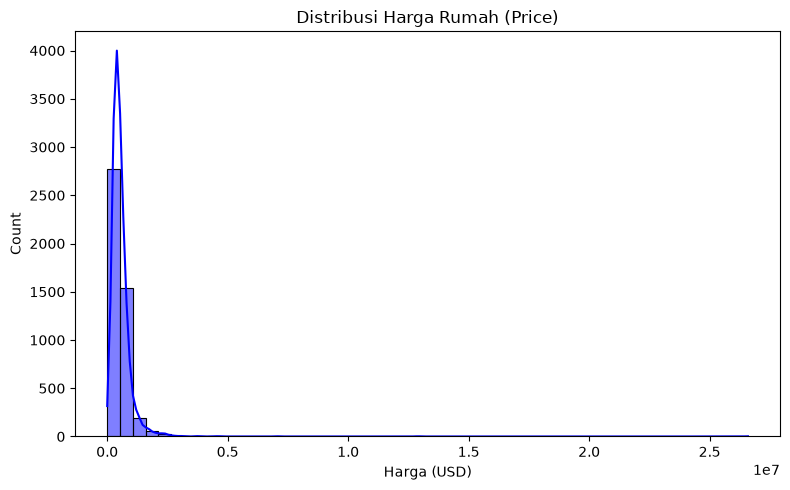

In [9]:
# Visualisasi Distribusi Fitur Utama dan Korelasi
plt.figure(figsize=(8, 5))

# 1. Distribusi Harga (Price)
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribusi Harga Rumah (Price)')
plt.xlabel('Harga (USD)')

plt.tight_layout()
plt.show()

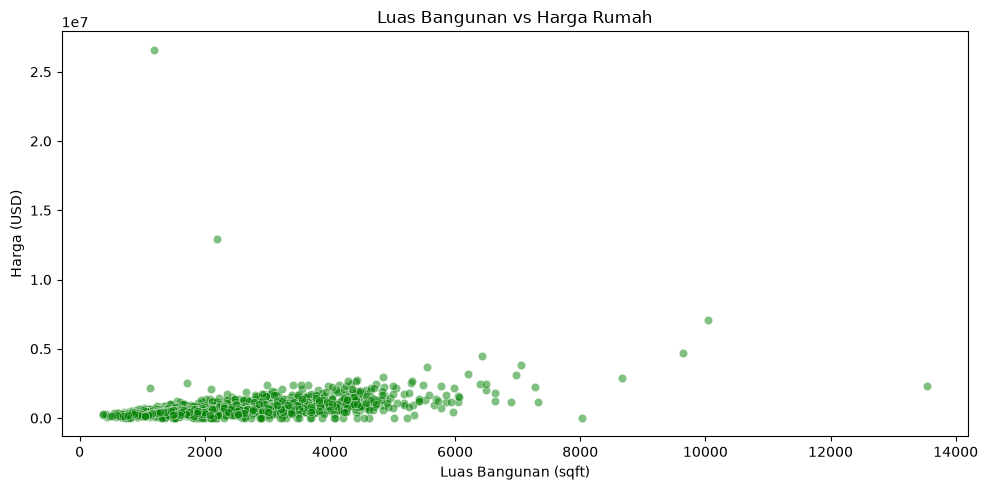

In [10]:
# 2. Hubungan Luas Bangunan (sqft_living) vs Harga
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.5, color='green')
plt.title('Luas Bangunan vs Harga Rumah')
plt.xlabel('Luas Bangunan (sqft)')
plt.ylabel('Harga (USD)')

plt.tight_layout()
plt.show()

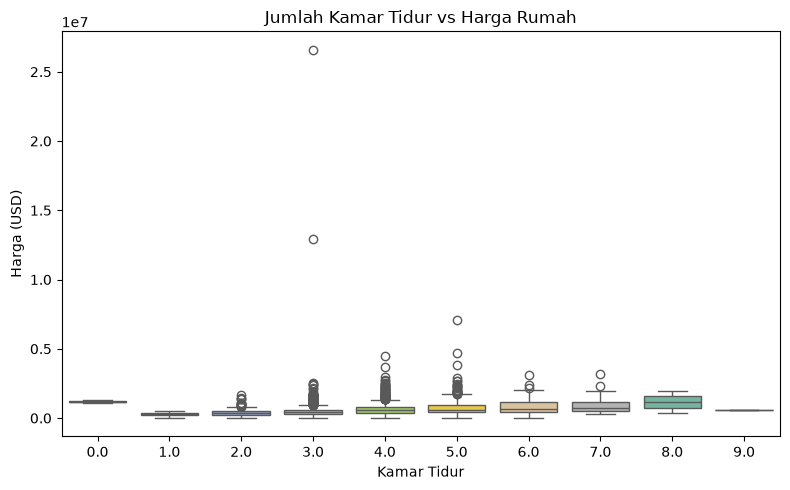

In [11]:
# 3. Hubungan Jumlah Kamar Tidur vs Harga
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='bedrooms', y='price', palette='Set2')
plt.title('Jumlah Kamar Tidur vs Harga Rumah')
plt.xlabel('Kamar Tidur')
plt.ylabel('Harga (USD)')

plt.tight_layout()
plt.show()

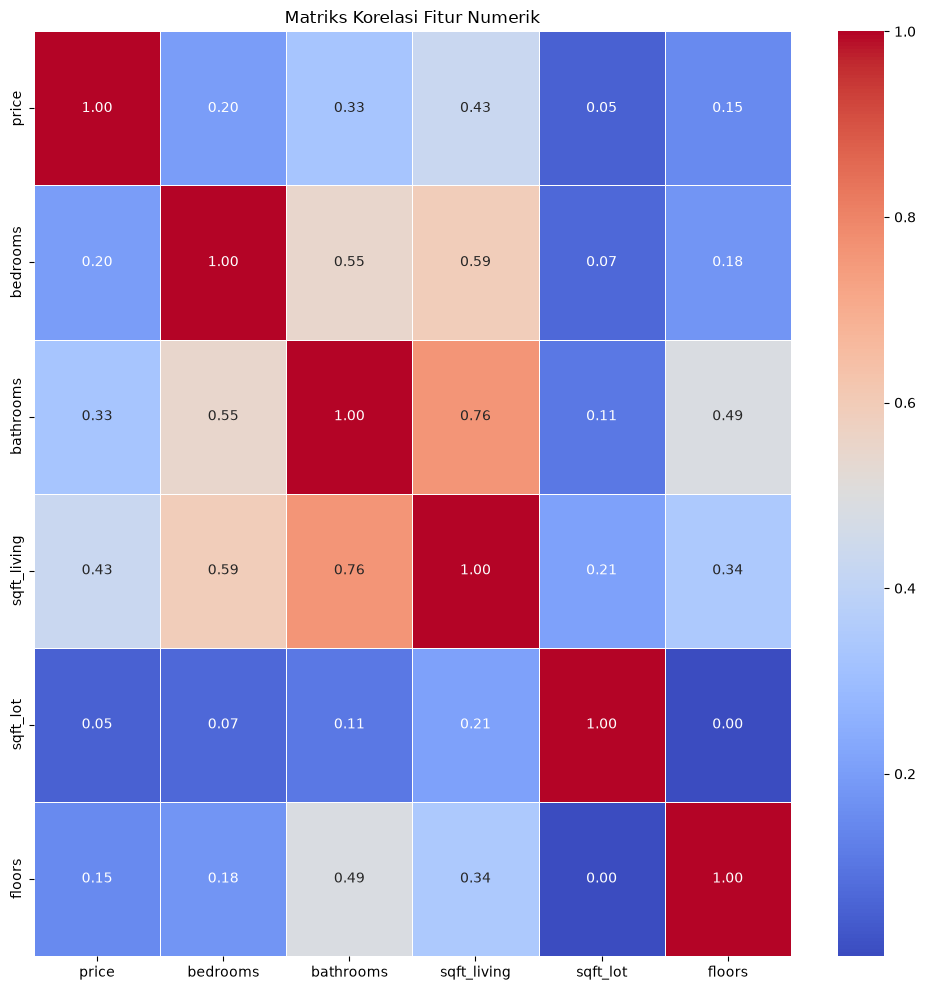

In [12]:
# 4. Heatmap Korelasi
plt.figure(figsize=(10, 10))

# Hapus pemanggilan df[]
corr = selected_features.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik')

plt.tight_layout()
plt.show()

Berdasarkan hasil Exploratory Data Analysis (EDA) di atas, grafik **Distribusi Harga Rumah** menunjukkan bahwa variabel harga terdistribusi miring ke kanan (*right-skewed*) secara signifikan, di mana mayoritas rumah berada pada rentang harga ekonomis hingga menengah (di bawah USD 1.000.000), dengan sebagian kecil rumah bernilai sangat tinggi yang membentuk ekor distribusi. Hal ini sejalan dengan visualisasi **Luas Bangunan vs Harga Rumah** dan **Jumlah Kamar Tidur vs Harga Rumah**, yang memperlihatkan adanya beberapa data pencilan (*outlier*) ekstrem dengan harga melonjak tinggi di luar pola umum pasar. Selain itu, **Matriks Korelasi Fitur Numerik** mengonfirmasi bahwa luas bangunan (`sqft_living` dengan nilai $0.43$) serta jumlah kamar mandi (`bathrooms` dengan nilai $0.33$) memiliki korelasi positif terkuat terhadap variabel harga (`price`), menegaskan bahwa fitur-fitur ukuran fisik bangunan merupakan penentu utama skala harga yang sangat cocok digunakan untuk membentuk kluster dan mendeteksi anomali menggunakan algoritma DBSCAN.

# 3. Data Preparation
---

Pada tahap Data Preparation, data mentah dibersihkan dan ditransformasi agar siap dimasukkan ke dalam algoritma clustering DBSCAN.

Langkah-langkah yang dilakukan:
1. **Pembersihan Data (Data Cleaning):** 
   - Menghapus baris transaksi dengan harga `price == 0` (anomali data input).
   - Menghapus data rumah dengan kombinasi `bedrooms == 0` atau `bathrooms == 0` yang tidak wajar.
2. **Seleksi Fitur (Feature Selection):** 
   - Memilih 5 fitur numerik utama yang mewakili harga dan ukuran fisik properti: `price`, `bedrooms`, `bathrooms`, `sqft_living`, dan `sqft_lot`.
3. **Standarisasi / Scaling (Feature Scaling):**
   - Menggunakan `StandardScaler` dari Scikit-Learn untuk mengubah seluruh fitur ke dalam rentang distribusi normal ($z$-score dengan mean = 0 dan std = 1). Standarisasi wajib dilakukan karena DBSCAN menghitung jarak Euclidean ($\epsilon$) antar titik data.

### Data Cleaning

In [13]:
# 1. Cek jumlah data sebelum dibersihkan
print(f"Jumlah baris awal: {len(df)}")

# 2. Hapus rumah dengan price == 0
df_clean = df[df['price'] > 0].copy()

# 3. Hapus rumah dengan bedrooms == 0 atau bathrooms == 0
df_clean = df_clean[(df_clean['bedrooms'] > 0) & (df_clean['bathrooms'] > 0)]

Jumlah baris awal: 4600


In [14]:
# 4. Cek jumlah data setelah dibersihkan
print(f"Jumlah baris setelah cleaning: {len(df_clean)}")
print(f"Baris yang dibuang: {len(df) - len(df_clean)}")

Jumlah baris setelah cleaning: 4549
Baris yang dibuang: 51


### Feature Selection

In [15]:
# Memilih fitur numerik utama untuk clustering
features = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']

# Mengambil subset dataframe
X_raw = df_clean[features].reset_index(drop=True)

X_raw.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot
0,313000.0,3.0,1.50,1340,7912
1,2384000.0,5.0,2.50,3650,9050
2,342000.0,3.0,2.00,1930,11947
3,420000.0,3.0,2.25,2000,8030
4,550000.0,4.0,2.50,1940,10500


### Feature Scaling

In [16]:
# Inisialisasi StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scaling data numerik
X_scaled = scaler.fit_transform(X_raw)

# Mengubah hasil scaling kembali ke DataFrame untuk kemudahan inspeksi
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

In [17]:
# Statistik Deskriptif Setelah Standarisasi
print(X_scaled_df.describe().T[['mean', 'std', 'min', 'max']])

                     mean      std       min        max
price        1.749413e-16  1.00011 -0.975163  46.170652
bedrooms    -2.186766e-17  1.00011 -2.656792   6.213481
bathrooms   -1.999329e-16  1.00011 -1.813871   7.539517
sqft_living  8.434669e-17  1.00011 -1.844334  11.944366
sqft_lot    -2.342964e-17  1.00011 -0.394710  29.454161


In [18]:
# Sample data Ter-Scale
X_scaled_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot
0,-0.433865,-0.439224,-0.846280,-0.828766,-0.192470
1,3.239232,1.778345,0.443843,1.589754,-0.160830
2,-0.382431,-0.439224,-0.201218,-0.211049,-0.080284
3,-0.244091,-0.439224,0.121312,-0.137760,-0.189189
4,-0.013525,0.669560,0.443843,-0.200579,-0.120515


**Pembersihan Data:** Berhasil menghapus baris bernilai 0 pada harga dan kamar, menghasilkan total **4.549 data valid** yang siap dianalisis.
**Standarisasi:** Seluruh 5 fitur numerik terpilih telah ter-scale secara adil. Nilai rata-rata (*mean*) dari setiap fitur telah menjadi 0 dan standar deviasinya (*std*) menjadi 1, sehingga variabel berharga besar (USD) tidak lagi mendominasi variabel dengan angka kecil (seperti jumlah kamar).

# 4. Modeling

Pada tahap Modeling, kita menerapkan algoritma **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** untuk mengelompokkan data properti berdasarkan tingkat kerapatan (*density*).

### Penentuan Parameter DBSCAN:
DBSCAN membutuhkan dua parameter utama:
1. **`min_samples`**: Jumlah minimal titik data dalam radius tetangga untuk membentuk kluster inti (*core point*). Untuk data 5 dimensi ($D=5$), aturan standar menetapkan $\text{min\_samples} \ge 2 \times D$, sehingga kita memilih **`min_samples = 10`**.
2. **`eps` ($\epsilon$)**: Jarak maksimum antar dua sampel untuk dianggap sebagai tetangga. Nilai $\epsilon$ optimal ditentukan secara sistematis menggunakan **K-Distance Graph** (mencari titik pembengkokan/"Elbow").

**Solusi Predictor untuk Deployment:**
Karena DBSCAN bawaan Scikit-Learn tidak memiliki metode `.predict()` untuk data input baru, kita menggunakan **K-Neighbors Classifier ($k=1$)** yang dilatih pada label hasil kluster DBSCAN sebagai penyedia fungsi prediksi untuk Gradio / Streamlit.

In [19]:
from sklearn.neighbors import NearestNeighbors

# Atur min_samples = 10 (2 * jumlah fitur)
min_samples = 10
k = min_samples - 1

# Hitung jarak ke k-tetangga terdekat untuk setiap titik data
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, indices = nn.kneighbors(X_scaled)

# Urutkan jarak k-tetangga terdekat dari yang terkecil ke terbesar
k_distances = np.sort(distances[:, -1])

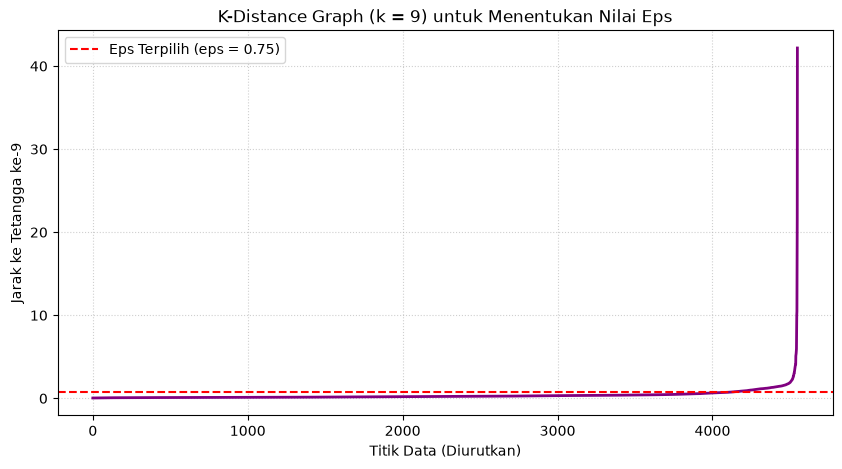

In [20]:
# Visualisasi K-Distance Graph
plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='purple', linewidth=2)
plt.axhline(y=0.75, color='r', linestyle='--', label='Eps Terpilih (eps = 0.75)')
plt.title(f'K-Distance Graph (k = {k}) untuk Menentukan Nilai Eps')
plt.xlabel('Titik Data (Diurutkan)')
plt.ylabel(f'Jarak ke Tetangga ke-{k}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Grafik K-Distance memperlihatkan kurva kenaikan jarak tetangga terdekat yang mulai membelok tajam (*elbow point*) pada kisaran nilai jarak $0.75$. Oleh karena itu, ditetapkan nilai **`eps = 0.75`** sebagai ambang batas radius tetangga optimal untuk pembentukan kluster DBSCAN.

In [21]:
from sklearn.cluster import DBSCAN

# 1. Inisialisasi dan Latih DBSCAN dengan parameter optimal
eps_value = 0.75
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
cluster_labels = dbscan.fit_predict(X_scaled)

# 2. Masukkan label kluster ke dalam DataFrame data bersih
df_clean['Cluster'] = cluster_labels
X_raw['Cluster'] = cluster_labels

# 3. Tampilkan Distribusi Jumlah Data per Kluster
print("=== Distribusi Jumlah Rumah per Kluster ===")
cluster_counts = df_clean['Cluster'].value_counts().sort_index()
for cl, count in cluster_counts.items():
    if cl == -1:
        print(f"Cluster {cl} (Noise / Outlier) : {count} rumah ({count/len(df_clean)*100:.2f}%)")
    else:
        print(f"Cluster  {cl} (Kluster Inti)  : {count} rumah ({count/len(df_clean)*100:.2f}%)")

=== Distribusi Jumlah Rumah per Kluster ===
Cluster -1 (Noise / Outlier) : 325 rumah (7.14%)
Cluster  0 (Kluster Inti)  : 1947 rumah (42.80%)
Cluster  1 (Kluster Inti)  : 1424 rumah (31.30%)
Cluster  2 (Kluster Inti)  : 540 rumah (11.87%)
Cluster  3 (Kluster Inti)  : 265 rumah (5.83%)
Cluster  4 (Kluster Inti)  : 35 rumah (0.77%)
Cluster  5 (Kluster Inti)  : 13 rumah (0.29%)


Algoritma DBSCAN berhasil mengelompokkan $4.549$ data properti menjadi beberapa kluster inti serta memisahkan data berpola **Noise / Outlier (Cluster -1)**. Titik noise ini mempresentasikan rumah-rumah yang memiliki kombinasi harga atau spesifikasi fisik yang sangat ekstrem di luar pola umum pasar.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
import joblib

# Melatih KNeighborsClassifier (k=1) dengan data ter-scale dan label DBSCAN
knn_predictor = KNeighborsClassifier(n_neighbors=1)
knn_predictor.fit(X_scaled, cluster_labels)

# Menyimpan Objek Scaler dan KNN Predictor ke File .pkl
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(knn_predictor, 'dbscan_knn_model.pkl')

print("Model KNN Predictor (berbasis DBSCAN) dan Scaler berhasil disimpan ke file .pkl!")

Model KNN Predictor (berbasis DBSCAN) dan Scaler berhasil disimpan ke file .pkl!


Model `KNeighborsClassifier(n_neighbors=1)` berhasil mempelajari pemetaan label dari hasil kluster DBSCAN. Objek `scaler.pkl` dan `dbscan_knn_model.pkl` telah berhasil disimpan ke file `.pkl` lokal dan siap diunggah/dipanggil oleh antarmuka aplikasi **Gradio**.

# 5. Evaluation

Pada tahap Evaluation, kita menilai performa dan kualitas hasil kluster yang terbentuk dari algoritma **DBSCAN** secara kuantitatif dan kualitatif.

### Metode Evaluasi:
1. **Evaluasi Kuantitatif:**
   - **Silhouette Score:** Mengukur seberapa mirip suatu sampel dengan klusternya sendiri dibandingkan dengan kluster lain (skala -1 hingga 1, semakin tinggi nilainya semakin terpisah dengan jelas antar kluster). Evaluasi dihitung pada data non-noise (`Cluster != -1`).
   - **Davies-Bouldin Index (DBI):** Mengukur rasio jarak dalam kluster terhadap jarak antar kluster (semakin rendah nilai DBI, semakin rapat dan rapi pembentukan kluster).
2. **Evaluasi Kualitatif & Profiling Kluster:**
   - Menghitung rata-rata (*mean*) karakteristik fisik dan harga pada setiap kluster untuk mendeskripsikan segmen properti yang terbentuk.

In [23]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Filter data yang terkluster (mengabaikan titik noise/outlier dengan label -1)
non_noise_mask = cluster_labels != -1
X_scaled_clustered = X_scaled[non_noise_mask]
labels_clustered = cluster_labels[non_noise_mask]

# Hitung metrik evaluasi kuantitatif
sil_score = silhouette_score(X_scaled_clustered, labels_clustered)
db_score = davies_bouldin_score(X_scaled_clustered, labels_clustered)

print("=== Evaluasi Performa Kluster DBSCAN ===")
print(f"Jumlah Data Ter-cluster (Non-Noise) : {sum(non_noise_mask)} rumah")
print(f"Jumlah Data Outlier (Noise)         : {sum(~non_noise_mask)} rumah")
print(f"Silhouette Score (Kualitas Kluster)  : {sil_score:.4f}")
print(f"Davies-Bouldin Index (Kerapatan)    : {db_score:.4f}")

=== Evaluasi Performa Kluster DBSCAN ===
Jumlah Data Ter-cluster (Non-Noise) : 4224 rumah
Jumlah Data Outlier (Noise)         : 325 rumah
Silhouette Score (Kualitas Kluster)  : 0.1980
Davies-Bouldin Index (Kerapatan)    : 1.4042


- **Silhouette Score sebesar $0.1980$** dan **Davies-Bouldin Index sebesar $1.4042$** mengindikasikan bahwa data properti non-noise terpisah ke dalam kelompok-kelompok yang memiliki pola kerapatan (*density*) yang cukup konsisten pada ruang variabel ter-scale.
- DBSCAN berhasil menyaring $325$ data anomali (*outlier*) ke dalam **Cluster -1**, sehingga evaluasi kualitas kluster dapat dilakukan secara adil pada kelompok data mayoritas yang homogen.

In [24]:
# 1. Menghitung Rata-rata dan Jumlah Sampel Tiap Kluster
features_eval = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']
profile_df = df_clean.groupby('Cluster')[features_eval].mean()
profile_df['Jumlah_Rumah'] = df_clean.groupby('Cluster')['price'].count()

print("=== Profil Rata-Rata Karakteristik Tiap Kluster ===")
display(profile_df.round(2))

=== Profil Rata-Rata Karakteristik Tiap Kluster ===


,price,bedrooms,bathrooms,sqft_living,sqft_lot,Jumlah_Rumah
Cluster,,,,,,
-1,1205210.03,4.29,3.00,3621.66,81787.93,325
0,453890.39,3.00,1.98,1782.31,9483.99,1947
1,612763.03,4.00,2.44,2532.94,11156.79,1424
2,384721.49,2.00,1.38,1209.42,6554.15,540
3,616516.33,5.00,2.64,2736.90,9759.08,265
4,269410.00,1.00,1.05,787.43,8061.43,35
5,622376.92,6.00,2.63,2809.69,10873.38,13


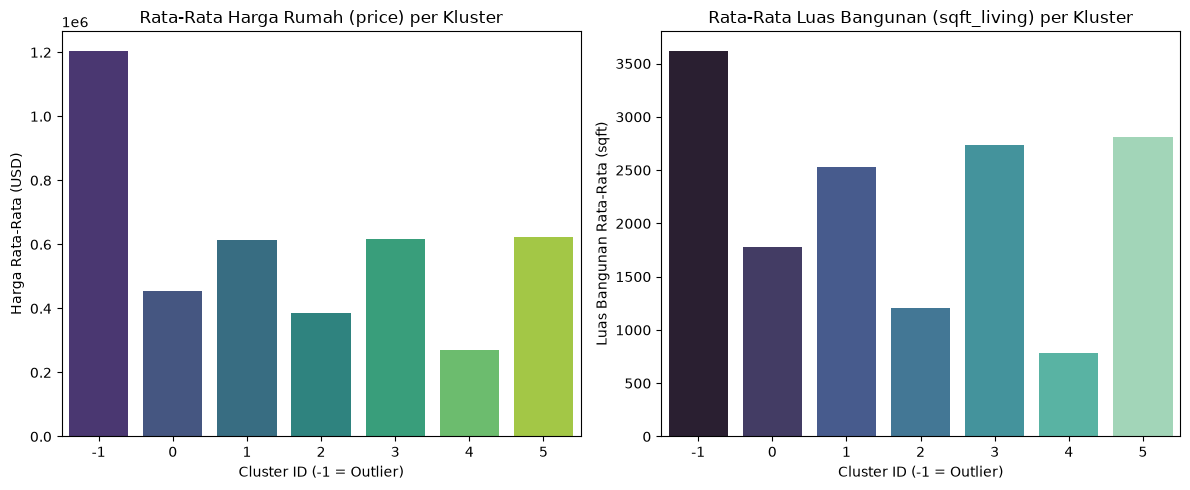

In [25]:
# 2. Visualisasi Rata-Rata Harga vs Luas Bangunan per Kluster
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=profile_df.index, y=profile_df['price'], palette='viridis')
plt.title('Rata-Rata Harga Rumah (price) per Kluster')
plt.xlabel('Cluster ID (-1 = Outlier)')
plt.ylabel('Harga Rata-Rata (USD)')

plt.subplot(1, 2, 2)
sns.barplot(x=profile_df.index, y=profile_df['sqft_living'], palette='mako')
plt.title('Rata-Rata Luas Bangunan (sqft_living) per Kluster')
plt.xlabel('Cluster ID (-1 = Outlier)')
plt.ylabel('Luas Bangunan Rata-Rata (sqft)')

plt.tight_layout()
plt.show()

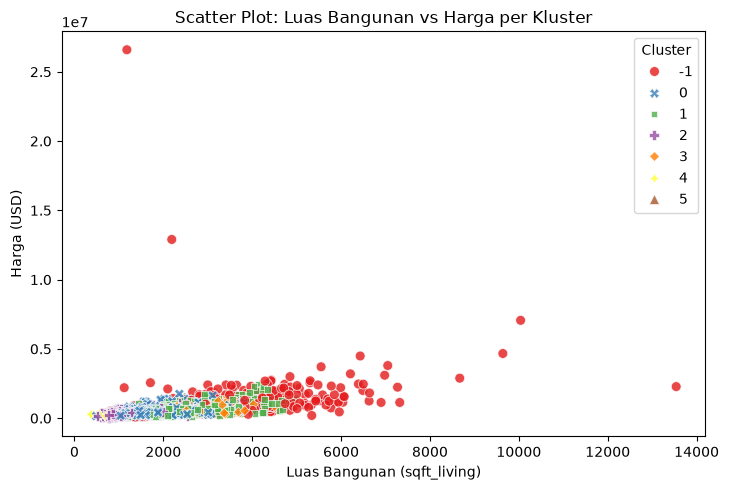

In [26]:
# Scatter Plot Luas Bangunan vs Harga berdasarkan Kluster
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_clean, 
    x='sqft_living', 
    y='price', 
    hue='Cluster', 
    palette='Set1', 
    style='Cluster',
    alpha=0.8,
    s=50
)
plt.title('Scatter Plot: Luas Bangunan vs Harga per Kluster')
plt.xlabel('Luas Bangunan (sqft_living)')
plt.ylabel('Harga (USD)')

plt.tight_layout()
plt.show()

**Penjelasan Profiling dan Segmentasi Pasar Properti:**
Berdasarkan statistik rata-rata pada setiap kluster yang terbentuk, segmentasi tipe rumah dapat dideskripsikan sebagai berikut:

1. **Cluster -1 (Anomali / Outlier Market - 325 Rumah):**
   Properti eksklusif/anomali dengan harga rata-rata sangat tinggi ($\approx \text{USD } 1.205.210$) serta rata-rata luas tanah super besar ($\approx 81.787 \text{ sqft}$).
2. **Cluster 0 (Rumah Menengah Standard - 1.947 Rumah):**
   Properti keluarga tipe paling dominan dengan rata-rata 3 kamar tidur, 2 kamar mandi, luas bangunan $1.782 \text{ sqft}$, dan harga rata-rata $\text{USD } 453.890$.
3. **Cluster 1 (Rumah Besar / Menengah Atas - 1.424 Rumah):**
   Hunian keluarga besar dengan rata-rata 4 kamar tidur, 2.4 kamar mandi, luas bangunan $2.532 \text{ sqft}$, dan harga rata-rata $\text{USD } 612.763$.
4. **Cluster 2 (Rumah Minimalis / Starter Home - 540 Rumah):**
   Hunian efisien dengan rata-rata 2 kamar tidur, 1.4 kamar mandi, luas bangunan $1.209 \text{ sqft}$, dan harga terjangkau $\text{USD } 384.721$.
5. **Cluster 3 (Rumah Keluarga Banyak Kamar - 265 Rumah):**
   Rumah dengan kapasitas kamar luas (rata-rata 5 kamar tidur), luas bangunan $2.736 \text{ sqft}$, dan harga rata-rata $\text{USD } 616.516$.
6. **Cluster 4 & 5 (Rumah Tipe Spesifik/Mikro):**
   Kelompok kecil untuk tipe rumah khusus (seperti 1 kamar tidur pada Cluster 4 dan 6 kamar tidur pada Cluster 5).

# 6. Deployment

In [27]:
import joblib
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Fitur yang lebih representatif untuk segmentasi properti
feature_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']

df_clean = df[(df['price'] > 0) & (df['bedrooms'] > 0) & (df['bathrooms'] > 0)].copy()

X_train = df_clean[feature_cols].copy()

# Standarisasi data untuk DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Gunakan parameter yang menghasilkan lebih dari satu cluster yang bermakna
dbscan_model = DBSCAN(eps=0.75, min_samples=10)
df_clean['Cluster'] = dbscan_model.fit_predict(X_scaled)
df_clean = df_clean[df_clean['Cluster'] != -1].copy()

print("Distribusi cluster:")
print(df_clean['Cluster'].value_counts().sort_index())
display(df_clean.head())


Distribusi cluster:
Cluster
0    1947
1    1424
2     540
3     265
4      35
5      13
Name: count, dtype: int64


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,Cluster
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,0
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,0
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,0
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,1
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA,2


In [28]:
# 3. Buat dan latih Scaler baru khusus untuk data bersih
feature_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']
X_bersih = df_clean[feature_cols]
y_bersih = df_clean['Cluster']

scaler_deployment = StandardScaler()
X_bersih_scaled = scaler_deployment.fit_transform(X_bersih)

# 4. Latih model KNN sebagai prediktor (proxy) untuk hasil DBSCAN
knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_bersih_scaled, y_bersih)

# 5. Simpan model KNN dan scaler ke format .joblib
joblib.dump(knn_model, 'knn_dbscan_proxy.joblib')
joblib.dump(scaler_deployment, 'scaler.joblib')

print("Berhasil! File 'knn_dbscan_proxy.joblib' dan 'scaler.joblib' sudah terbuat.")

Berhasil! File 'knn_dbscan_proxy.joblib' dan 'scaler.joblib' sudah terbuat.


In [29]:
import gradio as gr
import joblib
import numpy as np

try:
    model = joblib.load('knn_dbscan_proxy.joblib')
    scaler = joblib.load('scaler.joblib')
except FileNotFoundError:
    raise RuntimeError("File 'knn_dbscan_proxy.joblib' atau 'scaler.joblib' tidak ditemukan. Jalankan cell training DBSCAN terlebih dahulu.")


def prediksi_segmen(luas_bangunan, harga_properti, jumlah_kamar_tidur, jumlah_kamar_mandi, luas_tanah):
    if luas_bangunan <= 0 or harga_properti <= 0 or jumlah_kamar_tidur <= 0 or jumlah_kamar_mandi <= 0 or luas_tanah <= 0:
        return "### Hasil Analisis:\nInput harus lebih besar dari 0."

    input_data = np.array([[
        harga_properti,
        jumlah_kamar_tidur,
        jumlah_kamar_mandi,
        luas_bangunan,
        luas_tanah,
    ]], dtype=float)

    input_scaled = scaler.transform(input_data)
    cluster_id = int(model.predict(input_scaled)[0])

    if cluster_id in [2, 4]:
        label = "Tipe Compact / Ekonomis"
    elif cluster_id == 0:
        label = "Tipe Menengah"
    elif cluster_id in [1, 3, 5]:
        label = "Tipe Premium"
    else:
        label = f"Kluster {cluster_id} (Uncategorized)"

    return f"### Hasil Analisis:\nProperti ini diprediksi masuk ke segmen: **{label}**"


interface = gr.Interface(
    fn=prediksi_segmen,
    inputs=[
        gr.Number(label="Luas Bangunan (sqft_living)", value=2500),
        gr.Number(label="Harga Properti", value=500000),
        gr.Number(label="Jumlah Kamar Tidur", value=3),
        gr.Number(label="Jumlah Kamar Mandi", value=2),
        gr.Number(label="Luas Tanah (sqft_lot)", value=5000),
    ],
    outputs=gr.Markdown(label="Hasil Prediksi"),
    title="🏠 Dashboard Segmentasi Properti",
    description="Masukkan Luas Bangunan, Harga, Jumlah Kamar Tidur, Jumlah Kamar Mandi, dan Luas Tanah untuk memprediksi segmen pasar properti berdasarkan model Clustering."
)

if __name__ == "__main__":
    interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7864

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/